In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [5]:

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


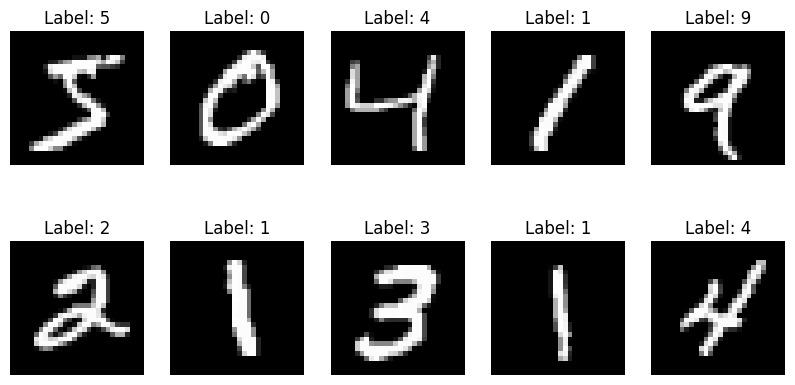

In [7]:

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

In [8]:

X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [10]:

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [11]:

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (60000, 28, 28, 1)
X_test Shape: (10000, 28, 28, 1)
y_train Shape: (60000, 10)
y_test Shape: (10000, 10)


In [12]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [13]:

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [17]:

history_adam = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 64s 159ms/step - accuracy: 0.8758 - loss: 0.4070 - val_accuracy: 0.8999 - val_loss: 0.3289
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - accuracy: 0.9562 - loss: 0.1484 - val_accuracy: 0.9830 - val_loss: 0.0591
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - accuracy: 0.9665 - loss: 0.1122 - val_accuracy: 0.9877 - val_loss: 0.0443
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 158ms/step - accuracy: 0.9732 - loss: 0.0903 - val_accuracy: 0.9870 - val_loss: 0.0498
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 58s 154ms/step - accuracy: 0.9746 - loss: 0.0826 - val_accuracy: 0.9875 - val_loss: 0.0455
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 157ms/step - accuracy: 0.9780 - loss: 0.0714 - val_accuracy: 0.9907 - val_loss: 0.0366
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.9799 - loss: 0.0667 - val_accuracy: 0.9893 - val_loss: 0.0405
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 154ms/step - accuracy: 0.9820 - loss: 0

In [18]:

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9908 - loss: 0.0290
Test Loss: 0.029011975973844528
Test Accuracy: 0.9908000230789185


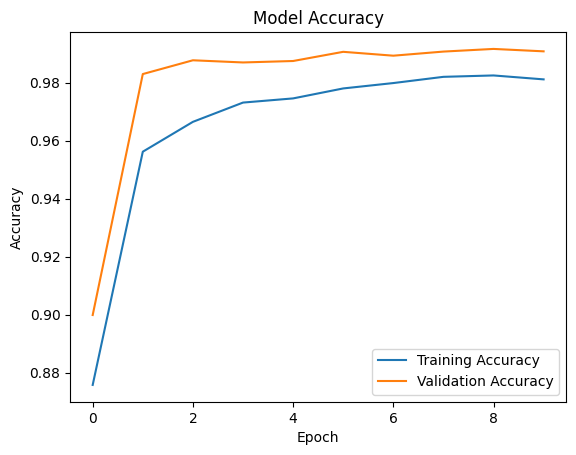

In [19]:

plt.plot(history_adam.history['accuracy'])
plt.plot(history_adam.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

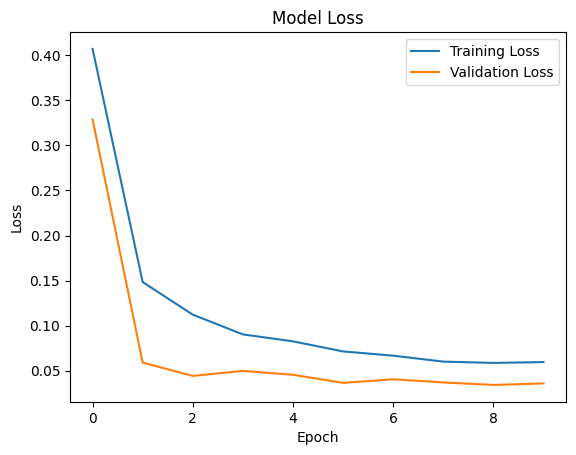

In [20]:

plt.plot(history_adam.history['loss'])
plt.plot(history_adam.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [21]:

model_sgd = Sequential()

model_sgd.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model_sgd.add(BatchNormalization())

model_sgd.add(MaxPooling2D(pool_size=(2,2)))

model_sgd.add(Dropout(0.25))

model_sgd.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model_sgd.add(BatchNormalization())

model_sgd.add(MaxPooling2D(pool_size=(2,2)))

model_sgd.add(Dropout(0.25))

model_sgd.add(Flatten())

model_sgd.add(Dense(
    128,
    activation='relu'
))

model_sgd.add(Dropout(0.5))

model_sgd.add(Dense(
    10,
    activation='softmax'
))

In [22]:

model_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:

history_sgd = model_sgd.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 157ms/step - accuracy: 0.7429 - loss: 0.8037 - val_accuracy: 0.8832 - val_loss: 0.4685
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 150ms/step - accuracy: 0.8937 - loss: 0.3446 - val_accuracy: 0.9658 - val_loss: 0.1184
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.9210 - loss: 0.2569 - val_accuracy: 0.9719 - val_loss: 0.0939
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 150ms/step - accuracy: 0.9331 - loss: 0.2170 - val_accuracy: 0.9758 - val_loss: 0.0806
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 153ms/step - accuracy: 0.9426 - loss: 0.1864 - val_accuracy: 0.9792 - val_loss: 0.0719
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 150ms/step - accuracy: 0.9483 - loss: 0.1729 - val_accuracy: 0.9807 - val_loss: 0.0665
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.9528 - loss: 0.1526 - val_accuracy: 0.9808 - val_loss: 0.0623
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 149ms/step - accuracy: 0.9552 - loss: 0

In [24]:

sgd_loss, sgd_accuracy = model_sgd.evaluate(X_test, y_test)

print("SGD Test Loss:", sgd_loss)
print("SGD Test Accuracy:", sgd_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9843 - loss: 0.0480
SGD Test Loss: 0.04799656942486763
SGD Test Accuracy: 0.9843000173568726
